# Notebook 5 — Modelo Support Vector Machine (SVM)

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())


Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
from src.config import Config
from src.evaluation import get_confusion_matrix, compute_metrics
from src.visualization import plot_confusion_matrix
from sklearn.metrics import classification_report

features_dir = Config.PROCESSED_DIR / 'features'
data = np.load(features_dir / 'emg_features_base.npz', allow_pickle=True)
meta = np.load(features_dir / 'emg_metadata_base.npz', allow_pickle=True)

X      = data['X']
y      = data['y']
splits = meta['splits']

train_idx = np.where(splits == 'train_samples')[0]
test_idx  = np.where(splits == 'test_samples')[0]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

class_names = sorted(np.unique(y).tolist())
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Clases:', class_names)


Train: (12500, 72)  |  Test: (6250, 72)
Clases: ['fist', 'open', 'pinch', 'waveIn', 'waveOut']


In [3]:
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(probability=True, random_state=42))
])

# Grid optimizado: más valores de C, kernel poly, gamma numéricos, cv=5
param_grid = [
    {
        'svm__C':      [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['rbf'],
        'svm__gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
    },
    {
        'svm__C':      [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear'],
    },
    {
        'svm__C':      [0.1, 1, 10],
        'svm__kernel': ['poly'],
        'svm__degree': [2, 3],
        'svm__gamma':  ['scale', 'auto'],
    },
]

print('Iniciando Grid Search SVM optimizado (puede tardar bastante)...')
grid_svm = GridSearchCV(pipeline_svm, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='f1_macro')
grid_svm.fit(X_train, y_train)
print('Mejores parámetros:', grid_svm.best_params_)
print('Mejor score CV:', grid_svm.best_score_)


Iniciando Grid Search SVM optimizado (puede tardar bastante)...
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Mejores parámetros: {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Mejor score CV: 0.8165691177599317


Reporte SVM:

              precision    recall  f1-score   support

        fist       0.87      0.92      0.90      1250
        open       0.82      0.85      0.83      1250
       pinch       0.85      0.83      0.84      1250
      waveIn       0.90      0.86      0.88      1250
     waveOut       0.94      0.92      0.93      1250

    accuracy                           0.88      6250
   macro avg       0.88      0.88      0.88      6250
weighted avg       0.88      0.88      0.88      6250



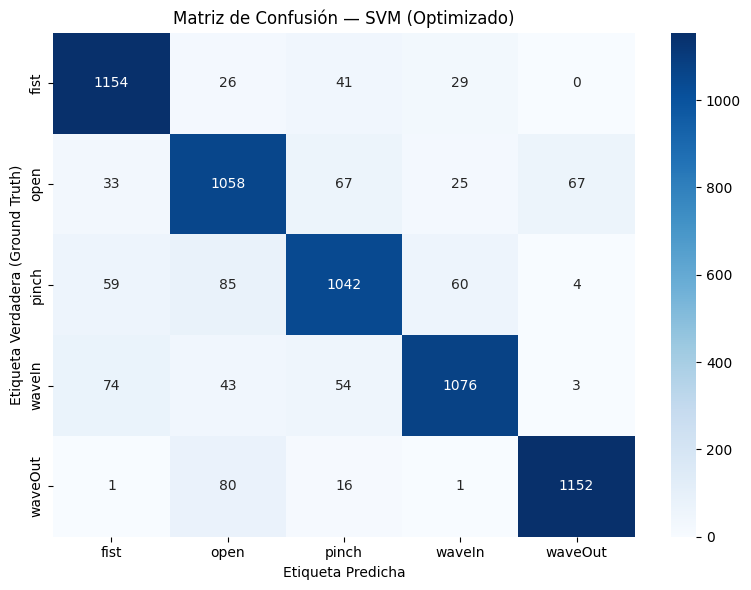

In [4]:
best_svm = grid_svm.best_estimator_
y_pred   = best_svm.predict(X_test)

print('Reporte SVM:\n')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = get_confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names, title='Matriz de Confusión — SVM (Optimizado)')


In [5]:
models_dir = Config.PROCESSED_DIR / 'models'
os.makedirs(models_dir, exist_ok=True)
joblib.dump(best_svm, models_dir / 'best_svm_model.pkl')
print('Modelo SVM guardado.')


Modelo SVM guardado.
